In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
import random

In [22]:
# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
	torch.cuda.manual_seed_all(seed)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Path to master file
try:
    repo_root = Path(__file__).resolve().parent.parent
except NameError: 
    repo_root = Path.cwd()
repo_root = repo_root.parent

repo_root = Path('C:/Users/shaun/Documents/GitHub/2025H5_GroupE')

DOCS  = repo_root / "data" / "clean_datasets"
CLEAN_FINAL_CSV = DOCS / "Final_master_daily_with_env.csv"

# Load data
df = pd.read_csv(CLEAN_FINAL_CSV, parse_dates=['DATE'], index_col='DATE')
df = df.sort_index()


In [24]:
## Model setup

# Select target
target = 'demand_mw_mean'

# Exclude leakage columns
exclude_cols = ['demand_mw_sum', 'demand_mw_mean', 'demand_mw_max', 'forecast_mw_sum', 'forecast_mw_mean', 'forecast_mw_max', 'fcst_error_mean', 'fcst_abs_error_sum', 'fcst_ape_mean'
				, 'F_P7_sin1', 'F_P7_cos1', 'F_P7_sin2', 'F_P7_cos2', 'F_P7_sin3', 'F_P7_cos3', 'F_P365_sin1', 'F_P365_cos1', 'F_P365_sin2', 'F_P365_cos2', 'F_P365_sin3', 'F_P365_cos3'
				, 'demand_mw_sum_lag1', 'demand_mw_sum_lag7', 'demand_mw_sum_lag14', 'demand_mw_sum_lag28', 'demand_mw_sum_roll7_mean', 'demand_mw_sum_roll7_std'
				, 'demand_mw_sum_roll14_mean', 'demand_mw_sum_roll14_std', 'temp_c_mean_lag1', 'temp_c_mean_lag7', 'forecast_mw_sum_lag1', 'forecast_mw_sum_lag7'
				, 'month', 'day', 'dow']
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Handle missing values: drop rows with NaN
df = df.dropna()

# Extract X (features) and y (target)
X = df[feature_cols].values
y = df[target].values

print(feature_cols)

['year', 'is_weekend', 'is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'cloud_cover', 'humidity', 'irradiance', 'precipitation', 'rn_temp_c', 'wind_speed', 'rn_temp_c_max', 'wind_speed_max', 'irradiance_max', 'precipitation_max', 'cloud_cover_max', 'humidity_max']


In [61]:
# Stationarity check on target
adf_result = adfuller(y)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
if adf_result[1] > 0.05:
	print("Series is non-stationary.")

# Function to create sequences
def create_sequences(X, y, lookback=365, horizon=28):
	Xs, ys = [], []
	for i in range(lookback, len(X) - horizon + 1):
		Xs.append(X[i - lookback:i])
		ys.append(y[i:i + horizon])
	return np.array(Xs), np.array(ys)

# Create sequences
lookback = 365 * 1
horizon = 28
dropout = 0.50
X_seq, y_seq = create_sequences(X, y, lookback, horizon)

# Calculate split sizes
N = len(df)
test_days = 393
test_size = test_days - horizon + 1  # 366
train_val_size = len(X_seq) - test_size
train_size = int(0.8 * train_val_size)
val_size = train_val_size - train_size

# Split sequences temporally
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_val_size], y_seq[train_size:train_val_size]
X_test, y_test = X_seq[train_val_size:], y_seq[train_val_size:]

# Scale data - fit on train, transform all
num_features = X.shape[1]
scaler_X = MinMaxScaler()
scaler_X.fit(X_train.reshape(-1, num_features))
X_train_scaled = scaler_X.transform(X_train.reshape(-1, num_features)).reshape(X_train.shape)
X_val_scaled = scaler_X.transform(X_val.reshape(-1, num_features)).reshape(X_val.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, num_features)).reshape(X_test.shape)

scaler_y = MinMaxScaler()
scaler_y.fit(y_train.reshape(-1, 1))
y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Custom Dataset
class TimeSeriesDataset(Dataset):
	def __init__(self, X, y):
		self.X = torch.tensor(X, dtype=torch.float32)
		self.y = torch.tensor(y, dtype=torch.float32)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]

# Create datasets and loaders
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


ADF Statistic: -5.482856398650892
p-value: 2.2638463865582283e-06


In [26]:
# Model 1: Fully Connected Network with Dropout
class FCModel(nn.Module):
	def __init__(self, input_size):
		super(FCModel, self).__init__()
		self.fc1 = nn.Linear(input_size, 128)
		self.dropout1 = nn.Dropout(dropout)
		self.fc2 = nn.Linear(128, 128)
		self.dropout2 = nn.Dropout(dropout)
		self.fc3 = nn.Linear(128, horizon)

	def forward(self, x):
		x = x.reshape(x.size(0), -1)  # Flatten, changed to reshape for contiguity
		x = torch.relu(self.fc1(x))
		x = self.dropout1(x)
		x = torch.relu(self.fc2(x))
		x = self.dropout2(x)
		x = self.fc3(x)
		return x

In [27]:
# Model 2: 1D CNN + FC with Dropout
class CNNModel(nn.Module):
	def __init__(self, input_channels, seq_len):
		super(CNNModel, self).__init__()
		self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=3, padding=1)
		self.pool = nn.MaxPool1d(2)
		self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
		self.flatten_size = 64 * (seq_len // 2)
		self.fc1 = nn.Linear(self.flatten_size, 64)
		self.dropout1 = nn.Dropout(dropout)
		self.fc2 = nn.Linear(64, 64)
		self.dropout2 = nn.Dropout(dropout)
		self.fc3 = nn.Linear(64, horizon)

	def forward(self, x):
		x = x.permute(0, 2, 1)  # (b, seq, feat) -> (b, feat, seq)
		x = torch.relu(self.conv1(x))
		x = self.pool(x)
		x = torch.relu(self.conv2(x))
		x = x.reshape(x.size(0), -1)  # Flatten, changed to reshape
		x = torch.relu(self.fc1(x))
		x = self.dropout1(x)
		x = torch.relu(self.fc2(x))
		x = self.dropout2(x)
		x = self.fc3(x)
		return x

In [28]:
# Model 3: Add LSTM model
class LSTMModel(nn.Module):
	def __init__(self, input_size, hidden_size, num_layers, output_size):
		super(LSTMModel, self).__init__()
		self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
		self.fc = nn.Linear(hidden_size, output_size)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		out, (h, c) = self.lstm(x)
		out = self.dropout(out[:, -1, :])
		out = self.fc(out)
		return out

In [29]:
# Training function with early stopping
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=5000, patience=50):
	best_loss = float('inf')
	patience_counter = 0
	for epoch in range(epochs):
		model.train()
		train_loss = 0
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			optimizer.zero_grad()
			output = model(X_batch)
			loss = criterion(output, y_batch)
			loss.backward()
			optimizer.step()
			train_loss += loss.item()
		train_loss /= len(train_loader)

		model.eval()
		val_loss = 0
		with torch.no_grad():
			for X_batch, y_batch in val_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				output = model(X_batch)
				val_loss += criterion(output, y_batch).item()
		val_loss /= len(val_loader)

		print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

		if val_loss < best_loss:
			best_loss = val_loss
			patience_counter = 0
		else:
			patience_counter += 1
			if patience_counter >= patience:
				print("Early stopping triggered.")
				break


In [63]:
# Initialize models
input_size_fc = lookback * num_features
model_fc = FCModel(input_size_fc).to(device)

input_channels_cnn = num_features
seq_len_cnn = lookback
model_cnn = CNNModel(input_channels_cnn, seq_len_cnn).to(device)

# LSTM parameters
hidden_size = 128
num_layers = 2
model_lstm = LSTMModel(num_features, hidden_size, num_layers, horizon).to(device)

# Optimizers and criterion
learning_rate = 1e-4
optimizer_fc = optim.Adam(model_fc.parameters(), lr=learning_rate)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=learning_rate)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=learning_rate)
criterion = nn.MSELoss()


In [31]:
# Function for prediction with uncertainty (Monte Carlo Dropout)
def predict_with_uncertainty(model, X_tensor, scaler_y, device, num_samples=100):
	model.train()  # Enable dropout
	preds = []
	with torch.no_grad():
		for _ in range(num_samples):
			output = model(X_tensor.to(device))
			preds.append(output.cpu().numpy())
	preds = np.stack(preds, axis=0)
	mean = np.mean(preds, axis=0)
	std = np.std(preds, axis=0)
	mean_inv = scaler_y.inverse_transform(mean)
	std_inv = std * (scaler_y.data_max_ - scaler_y.data_min_)  # Approximate scaling for std
	return mean_inv, std_inv

# Function for standard prediction, with option to return scaled
def predict(model, X_scaled, scaler_y, device, return_scaled=False):
	model.eval()
	with torch.no_grad():
		X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
		pred_scaled = model(X_tensor).cpu().numpy()
		if return_scaled:
			return pred_scaled
		pred = scaler_y.inverse_transform(pred_scaled)
		return pred

In [64]:
# Train models
print("Training Fully Connected Network...")
train_model(model_fc, train_loader, val_loader, optimizer_fc, criterion)

print("Training 1D CNN + FC Network...")
train_model(model_cnn, train_loader, val_loader, optimizer_cnn, criterion)

##print("Training LSTM Network...")
##train_model(model_lstm, train_loader, val_loader, optimizer_lstm, criterion)


Training Fully Connected Network...
Epoch 1/5000, Train Loss: 0.0734, Val Loss: 0.0351
Epoch 2/5000, Train Loss: 0.0478, Val Loss: 0.0291
Epoch 3/5000, Train Loss: 0.0379, Val Loss: 0.0310
Epoch 4/5000, Train Loss: 0.0330, Val Loss: 0.0316
Epoch 5/5000, Train Loss: 0.0299, Val Loss: 0.0308
Epoch 6/5000, Train Loss: 0.0289, Val Loss: 0.0312
Epoch 7/5000, Train Loss: 0.0274, Val Loss: 0.0214
Epoch 8/5000, Train Loss: 0.0242, Val Loss: 0.0219
Epoch 9/5000, Train Loss: 0.0234, Val Loss: 0.0206
Epoch 10/5000, Train Loss: 0.0227, Val Loss: 0.0186
Epoch 11/5000, Train Loss: 0.0212, Val Loss: 0.0216
Epoch 12/5000, Train Loss: 0.0201, Val Loss: 0.0166
Epoch 13/5000, Train Loss: 0.0199, Val Loss: 0.0193
Epoch 14/5000, Train Loss: 0.0200, Val Loss: 0.0186
Epoch 15/5000, Train Loss: 0.0185, Val Loss: 0.0132
Epoch 16/5000, Train Loss: 0.0180, Val Loss: 0.0177
Epoch 17/5000, Train Loss: 0.0170, Val Loss: 0.0124
Epoch 18/5000, Train Loss: 0.0167, Val Loss: 0.0148
Epoch 19/5000, Train Loss: 0.0166, Va

In [65]:
# Predict on test set (unscaled)
pred_fc = predict(model_fc, X_test_scaled, scaler_y, device)
pred_cnn = predict(model_cnn, X_test_scaled, scaler_y, device)
##pred_lstm = predict(model_lstm, X_test_scaled, scaler_y, device)

# Predict scaled for residuals
pred_fc_scaled = predict(model_fc, X_test_scaled, scaler_y, device, return_scaled=True)
pred_cnn_scaled = predict(model_cnn, X_test_scaled, scaler_y, device, return_scaled=True)
##pred_lstm_scaled = predict(model_lstm, X_test_scaled, scaler_y, device, return_scaled=True)

# Evaluate overall (unscaled)
mae_fc = mean_absolute_error(y_test, pred_fc)
rmse_fc = np.sqrt(mean_squared_error(y_test, pred_fc))
print(f"Fully Connected - MAE: {mae_fc}, RMSE: {rmse_fc}")

mae_cnn = mean_absolute_error(y_test, pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test, pred_cnn))
print(f"1D CNN + FC - MAE: {mae_cnn}, RMSE: {rmse_cnn}")

##mae_lstm = mean_absolute_error(y_test, pred_lstm)
##rmse_lstm = np.sqrt(mean_squared_error(y_test, pred_lstm))
##print(f"LSTM - MAE: {mae_lstm}, RMSE: {rmse_lstm}")

# Per horizon metrics (unscaled)
mae_per_h_fc = np.mean(np.abs(y_test - pred_fc), axis=0)
rmse_per_h_fc = np.sqrt(np.mean((y_test - pred_fc)**2, axis=0))

# Future prediction: Next 28 days from the end of dataset
X_future = X[-lookback:]
X_future_scaled = scaler_X.transform(X_future.reshape(-1, num_features)).reshape(1, lookback, num_features)
pred_future_fc = predict(model_fc, X_future_scaled, scaler_y, device)[0]
print("Future 28 days prediction (FC):", pred_future_fc)


Fully Connected - MAE: 584.6900278881129, RMSE: 763.193116742591
1D CNN + FC - MAE: 389.6116310852053, RMSE: 506.0501077338723
Future 28 days prediction (FC): [7716.2627 7691.686  7723.5835 7744.9185 7762.8076 7752.2583 7714.648
 7674.6304 7667.0825 7691.4556 7747.8945 7764.2173 7742.3667 7669.2563
 7649.907  7659.2134 7689.3037 7749.8438 7739.2505 7722.8384 7695.308
 7675.518  7651.6567 7697.324  7772.8545 7790.63   7745.8276 7718.9985]


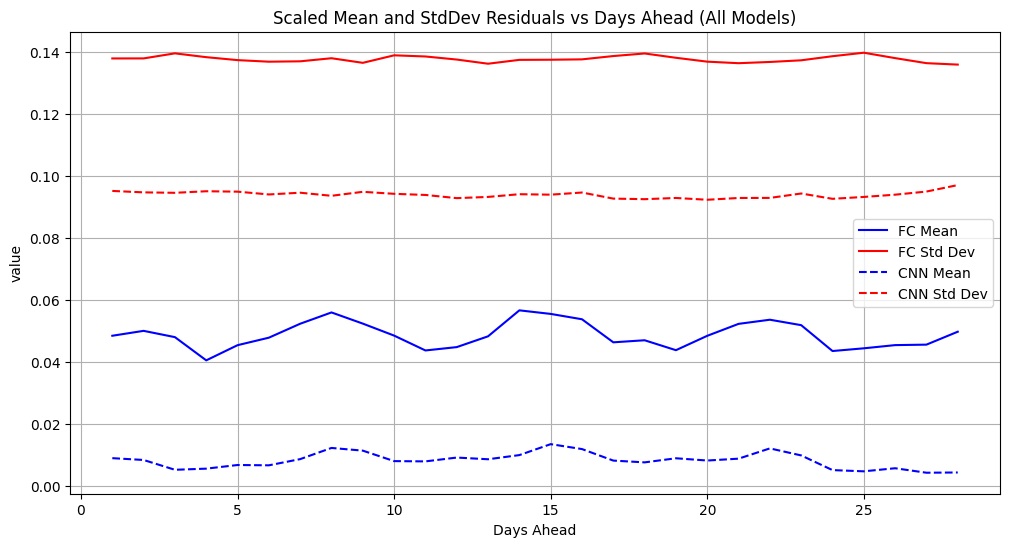

In [35]:
# New plots

# Plot a): Mean and std of scaled residuals vs days ahead, for all models overlapped
models = {'FC': (y_test_scaled - pred_fc_scaled), 'CNN': (y_test_scaled - pred_cnn_scaled)}#, 'LSTM': (y_test_scaled - pred_lstm_scaled)}
line_styles = {'FC': '-', 'CNN': '--'}#, 'LSTM': ':'}  # Solid, dashed, dotted
colors_mean = {'FC': 'blue', 'CNN': 'blue'}#, 'LSTM': 'blue'}
colors_std = {'FC': 'red', 'CNN': 'red'}#, 'LSTM': 'red'}

# Compute means and stds
means = {name: np.mean(res_scaled, axis=0) for name, res_scaled in models.items()}
stds = {name: np.std(res_scaled, axis=0) for name, res_scaled in models.items()}
days_ahead = np.arange(1, horizon + 1)

# Plot for Mean Scaled Residuals
plt.figure(figsize=(12, 6))
for name in models:
	plt.plot(days_ahead, means[name], linestyle=line_styles[name], color=colors_mean[name], label=f'{name} Mean')
	plt.plot(days_ahead, stds[name], linestyle=line_styles[name], color=colors_std[name], label=f'{name} Std Dev')
plt.xlabel('Days Ahead')
plt.ylabel('value')
plt.title('Scaled Mean and StdDev Residuals vs Days Ahead (All Models)')
plt.legend()
plt.grid(True)
plt.show()


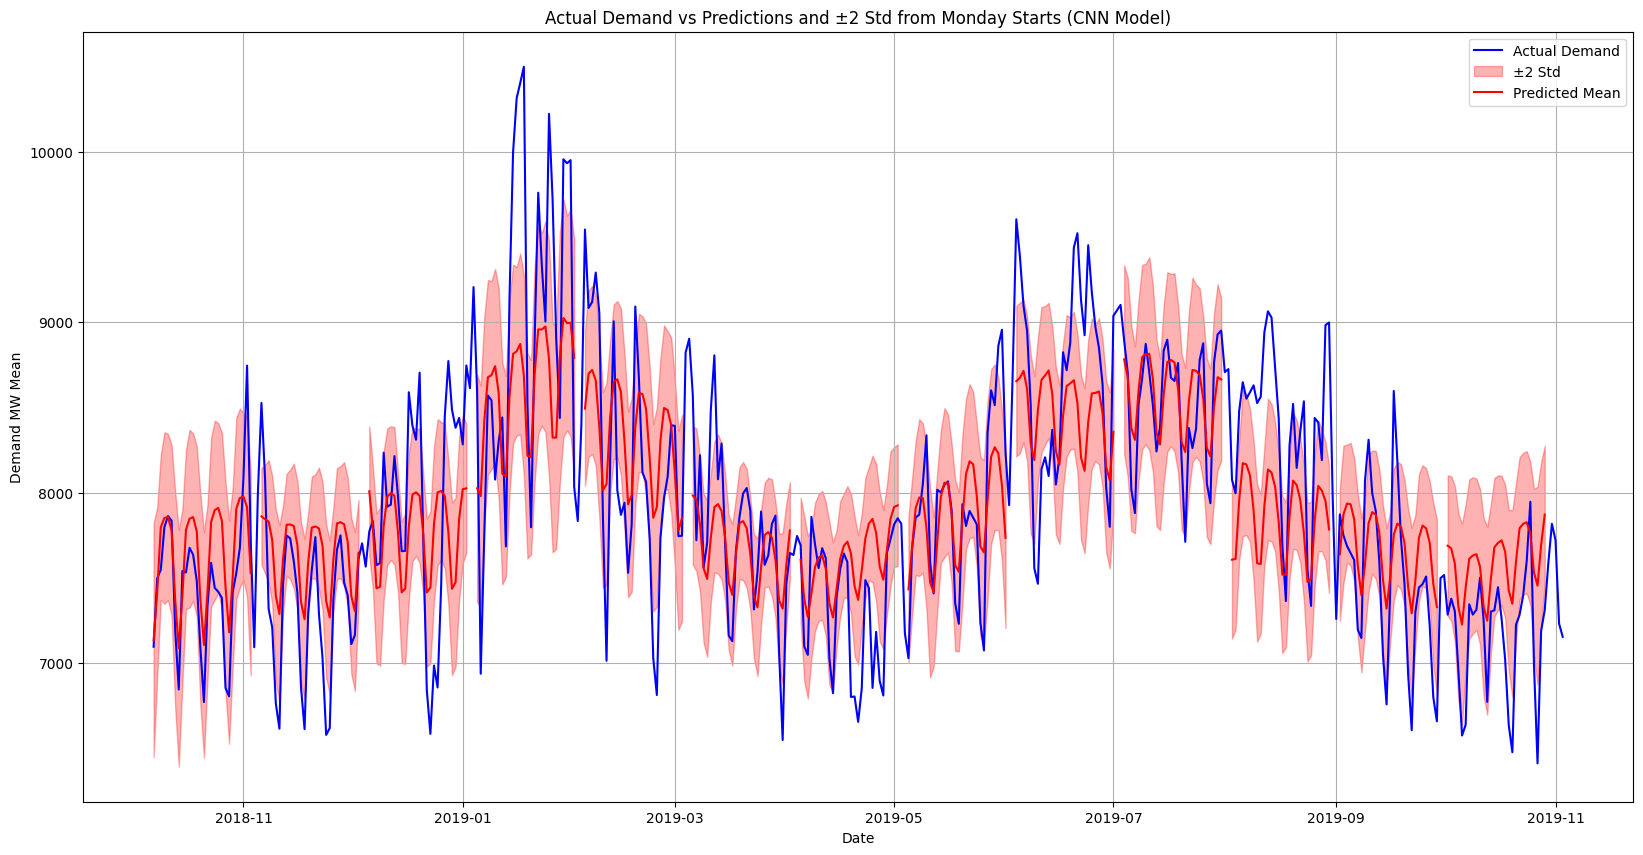

In [37]:
# Plot b): Time series with actuals and predictions + bounds starting from Mondays (using FC model)
# Get test starting indices
seq_start_idx = lookback + train_val_size
test_start_dates = df.index[seq_start_idx : seq_start_idx + test_size]

# Test period dates
test_period_start = test_start_dates[0]
test_period_end = df.index[-1]
test_dates = df.index[(df.index >= test_period_start) & (df.index <= test_period_end)]
actuals = df.loc[test_dates, target].values

plt.figure(figsize=(20, 10))
plt.plot(test_dates, actuals, 'b-', label='Actual Demand')

# Find Monday starts (dow==0)
plot_indices = []
for k in range(test_size):
	if k%30 == 0:
		plot_indices.append(k)

# For each Monday start, compute pred and std with uncertainty, plot lines
for k in plot_indices:
	X_k = torch.tensor(X_test_scaled[k:k+1], dtype=torch.float32)
	mean_inv, std_inv = predict_with_uncertainty(model_cnn, X_k, scaler_y, device)
	mean_inv = mean_inv.flatten()
	std_inv = std_inv.flatten()
	pred_dates = df.index[seq_start_idx + k : seq_start_idx + k + horizon]
	##plt.fill_between(pred_dates, mean_inv - 3 * std_inv, mean_inv + 3 * std_inv, color='red', alpha=0.1, label='±3 Std' if k == plot_indices[0] else None)
	plt.fill_between(pred_dates, mean_inv - 2 * std_inv, mean_inv + 2 * std_inv, color='red', alpha=0.3, label='±2 Std' if k == plot_indices[0] else None)
	plt.plot(pred_dates, mean_inv, color='red', linestyle='-', label='Predicted Mean' if k == plot_indices[0] else None)

plt.xlabel('Date')
plt.ylabel('Demand MW Mean')
plt.title('Actual Demand vs Predictions and ±2 Std from Monday Starts (CNN Model)')
plt.legend()
plt.grid(True)
plt.show()

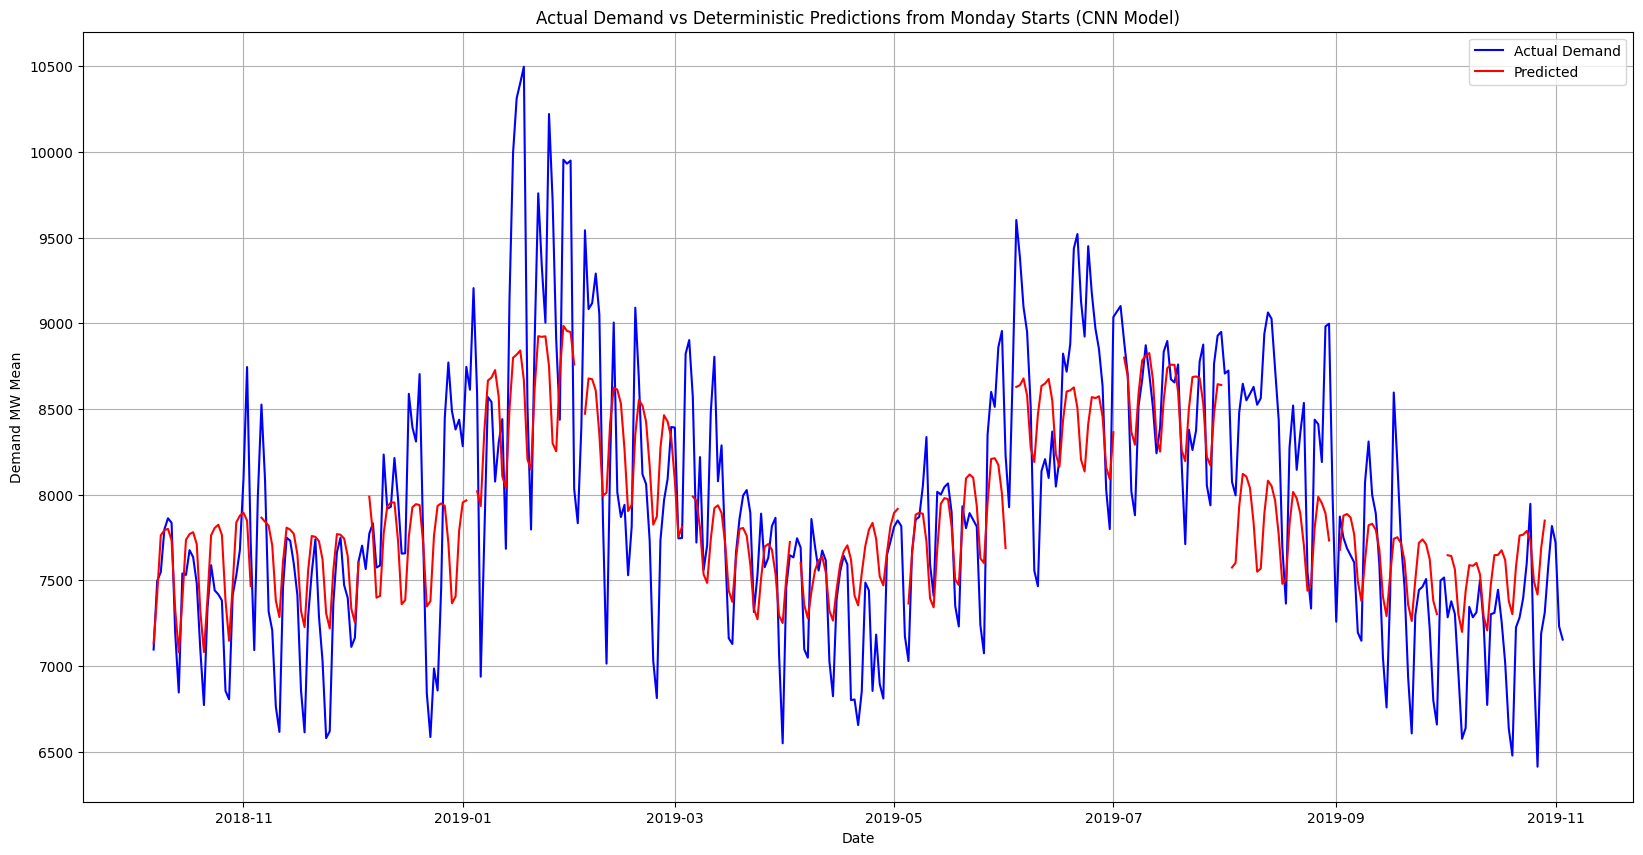

In [38]:
# Plot c): Deterministic version of plot b
plt.figure(figsize=(20, 10))
plt.plot(test_dates, actuals, 'b-', label='Actual Demand')

# For each Monday start, compute deterministic pred, plot line
for k in plot_indices:
	X_k = torch.tensor(X_test_scaled[k:k+1], dtype=torch.float32)
	pred = predict(model_cnn, X_test_scaled[k:k+1], scaler_y, device)
	pred = pred.flatten()
	pred_dates = df.index[seq_start_idx + k : seq_start_idx + k + horizon]
	plt.plot(pred_dates, pred, color='red', linestyle='-', label='Predicted' if k == plot_indices[0] else None)

plt.xlabel('Date')
plt.ylabel('Demand MW Mean')
plt.title('Actual Demand vs Deterministic Predictions from Monday Starts (CNN Model)')
plt.legend()
plt.grid(True)
plt.show()



##a = input("Pausing to keep windows open")

In [66]:
## Evaluate CNN model over validation data

# Rolling 28days over the validation period
horizon = y_test.shape[1]

mae_by_pt  = []
bias_by_pt = []

for k in range(horizon):
    yt = y_test[:, k]
    yp = pred_cnn[:, k]
    mae_by_pt.append(mean_absolute_error(yt, yp))
    bias_by_pt.append(np.mean(yp - yt))   # >0 overpredict, <0 underpredict

for k, (mae, bias) in enumerate(zip(mae_by_pt, bias_by_pt), start=1):
    print(f"Day {k:2d}: MAE={mae:.3f}, Bias={bias:.3f}")


Day  1: MAE=378.245, Bias=32.072
Day  2: MAE=378.838, Bias=32.765
Day  3: MAE=389.116, Bias=38.339
Day  4: MAE=376.789, Bias=40.170
Day  5: MAE=384.219, Bias=49.706
Day  6: MAE=387.557, Bias=54.732
Day  7: MAE=380.899, Bias=42.195
Day  8: MAE=372.217, Bias=28.888
Day  9: MAE=376.707, Bias=30.779
Day 10: MAE=383.326, Bias=36.215
Day 11: MAE=375.806, Bias=37.853
Day 12: MAE=381.173, Bias=48.058
Day 13: MAE=384.323, Bias=54.580
Day 14: MAE=378.820, Bias=45.769
Day 15: MAE=373.518, Bias=37.522
Day 16: MAE=377.511, Bias=40.104
Day 17: MAE=387.838, Bias=47.662
Day 18: MAE=386.101, Bias=52.988
Day 19: MAE=394.057, Bias=60.876
Day 20: MAE=398.496, Bias=69.707
Day 21: MAE=396.651, Bias=60.439
Day 22: MAE=390.096, Bias=51.713
Day 23: MAE=398.286, Bias=56.770
Day 24: MAE=410.508, Bias=61.824
Day 25: MAE=404.248, Bias=62.692
Day 26: MAE=418.006, Bias=71.974
Day 27: MAE=424.427, Bias=77.026
Day 28: MAE=421.349, Bias=68.537
